In [ ]:
# Install SHAP if it is not already installed
!pip install shap

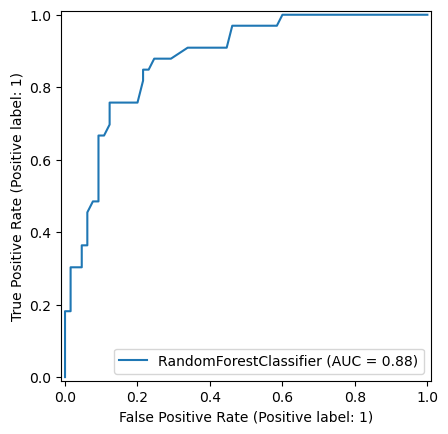

The accuracy of the Random Forest model is:	 0.7959183673469388


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
import shap
from sklearn import metrics

# --- Load and preprocess the dataset ---
df = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
    header=None
)

# Define feature names
feature = [
    "pregnant", "glucose", "diastolic BP", "subcutaneous fat",
    "serum insulin", "BMI", "diabetes pedigree function", "age", "Diabetes(=1)"
]
df.columns = feature

# Remove rows with invalid (zero) values in key features
df2 = df[
    (df["glucose"] != 0) &
    (df["diastolic BP"] != 0) &
    (df["subcutaneous fat"] != 0) &
    (df["serum insulin"] != 0) &
    (df["BMI"] != 0)
]

# Separate features and target variable
X = df2.iloc[:, :-1]
y = df2.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# --- Train model and display ROC curve ---
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train, y_train)

# Plot ROC curve
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.show()

# Display accuracy
clf_pred = clf.predict(X_test)
print('The accuracy of the Random Forest model is:\t', metrics.accuracy_score(clf_pred, y_test))


In [4]:
# --- SHAP Analysis ---
print("\n--- Using shap.Explainer (New API) ---")

try:
    # Create the SHAP explainer using the model (masker is not required for tree-based models)
    # explainer_new = shap.Explainer(clf, X_train)  # Optional: explicitly specify masker
    explainer_new = shap.Explainer(clf)             # Recommended for tree-based models like RandomForest

    # Compute SHAP values as an Explanation object
    shap_values_obj = explainer_new(X_test)

    # Inspect the Explanation object (for debugging purposes)
    print(f"Type of shap_values_obj: {type(shap_values_obj)}")

    if hasattr(shap_values_obj, 'values'):
        print(f"Shape of shap_values_obj.values: {shap_values_obj.values.shape}")

        # Select SHAP values for class 1 (assumes last axis corresponds to class labels)
        shap_values_class1 = shap_values_obj.values[:, :, 1]
        print(f"Shape of selected SHAP values for class 1: {shap_values_class1.shape}")

        # Confirm feature count matches input data
        assert shap_values_class1.shape[1] == X_test.shape[1], \
            f"Mismatch: SHAP features ({shap_values_class1.shape[1]}) != X_test features ({X_test.shape[1]})"

        # Plot summary for class 1 and save as high-resolution TIFF
        fig = plt.figure()
        shap.summary_plot(shap_values_class1, X_test, plot_type="dot", show=False)
        plt.savefig("shap_summary_plot_class1.tiff", format='tiff', dpi=600)
        plt.close(fig)
        print("SHAP summary plot (New API, class 1 selected) generated successfully.")

    elif hasattr(shap_values_obj, 'shape') and len(shap_values_obj.shape) == 2:
        # Fallback for models with binary output (no explicit class dimension)
        print(f"Shape of shap_values_obj: {shap_values_obj.shape}")
        print("Warning: Explanation object appears to be 2D. Attempting to plot directly.")
        shap.summary_plot(shap_values_obj, X_test, plot_type="dot")
        plt.show()
        print("SHAP summary plot (New API, direct object) generated successfully.")

    else:
        # Generic fallback if class structure is unclear
        print("Trying to plot Explanation object directly...")
        shap.summary_plot(shap_values_obj, X_test, plot_type="dot")
        plt.show()
        print("SHAP summary plot (New API, direct object - auto class?) generated successfully.")

except Exception as e:
    print(f"An error occurred with the new API: {e}")



--- Using shap.Explainer (New API) ---
Type of shap_values_obj: <class 'shap._explanation.Explanation'>
Shape of shap_values_obj.values: (98, 8, 2)
Shape of selected SHAP values for class 1: (98, 8)
SHAP summary plot (New API, class 1 selected) generated successfully.
